# Heart Disease Prediction using Support Vector Machine (SVM)

This notebook demonstrates how to build and evaluate a Support Vector Classifier (SVC) to predict the presence of heart disease in patients.

### 1. Import Libraries
We start by importing the necessary libraries for data manipulation, visualization, preprocessing, and model evaluation.


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

### 2. Load the Dataset
We load the heart disease dataset (`heart.csv`) using pandas to begin our analysis.


In [57]:
dataset = "../../Datasets/heart.csv"

df = pd.read_csv(dataset)

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


### 3. Exploratory Data Analysis (EDA)
We print the first and last 5 rows of the dataset to get an initial overview of our features and values.


In [58]:
print(df.head())
print()
print(df.tail())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.

### 4. Check Dataset Shape
We check the total number of records (rows) and attributes (columns) present in the dataset.


In [59]:
df.shape

(1025, 14)

### 5. Inspect Column Names
We list all the feature and target column names.


In [60]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

### 6. Dataset Info
We check the data types, non-null counts, and memory usage for each column to understand our data structure.


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### 7. Statistical Summary
We generate descriptive statistics (mean, standard deviation, min, max, quartiles) for all numerical columns.


In [62]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### 8. Check for Missing Values
We verify if there are any missing (null) values in our columns that would require imputation.


In [63]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### 9. Check for Duplicate Rows
We identify if there are any duplicate records in the dataset to avoid training bias.


In [64]:
df.duplicated().sum()

np.int64(723)

### 10. Data Cleaning - Drop Duplicates
We drop the duplicate rows from the dataset to ensure clean, unique data.


In [65]:
df.drop_duplicates(inplace=True)
print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (302, 14)


### 11. Data Visualization
We visualize the target class distribution, age distribution, chest pain type distribution, and generate a correlation heatmap to analyze the relationships between features.


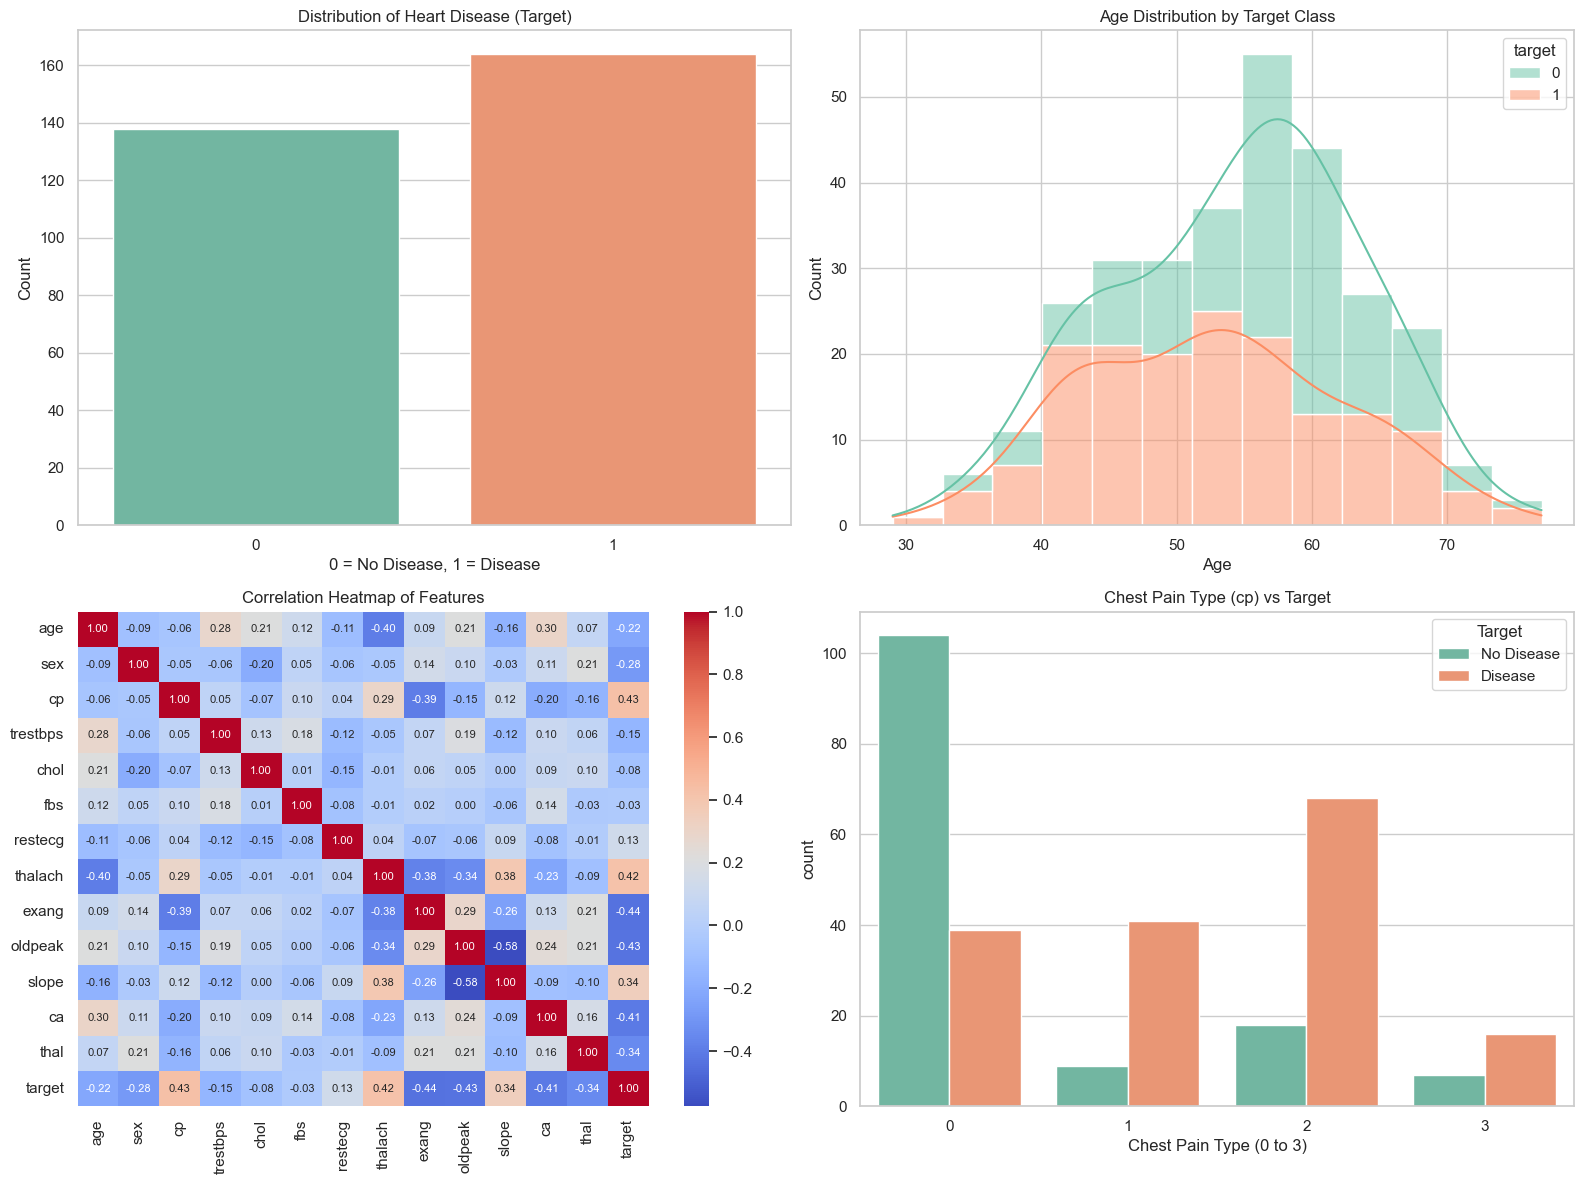

In [66]:
# Set seaborn theme for beautiful styling
sns.set_theme(style="whitegrid")

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Target Class Distribution (Is the dataset balanced?)
sns.countplot(x="target", data=df, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Distribution of Heart Disease (Target)")
axes[0, 0].set_xlabel("0 = No Disease, 1 = Disease")
axes[0, 0].set_ylabel("Count")

# 2. Age Distribution by Target (Does age affect heart disease rate?)
sns.histplot(x="age", hue="target", data=df, kde=True, ax=axes[0, 1], palette="Set2", multiple="stack")
axes[0, 1].set_title("Age Distribution by Target Class")
axes[0, 1].set_xlabel("Age")

# 3. Correlation Heatmap (How do features relate to each other and the target?)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 0], cbar=True, annot_kws={"size": 8})
axes[1, 0].set_title("Correlation Heatmap of Features")

# 4. Chest Pain Type vs Target (Which chest pain types are most critical?)
sns.countplot(x="cp", hue="target", data=df, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Chest Pain Type (cp) vs Target")
axes[1, 1].set_xlabel("Chest Pain Type (0 to 3)")
axes[1, 1].legend(title="Target", labels=["No Disease", "Disease"])

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


### 12. Categorical Encoding (One-Hot Encoding)
We apply One-Hot Encoding to the nominal categorical features (`cp`, `restecg`, `slope`, `thal`) using `pd.get_dummies` to convert them into machine-readable binary columns (0 and 1).


In [67]:
df = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True, dtype=int)

df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,0,0,0,0,1,0,0,1,0,0,1
1,53,1,140,203,1,155,1,3.1,0,0,0,0,0,0,0,0,0,0,0,1
2,70,1,145,174,0,125,1,2.6,0,0,0,0,0,1,0,0,0,0,0,1
3,61,1,148,203,0,161,0,0.0,1,0,0,0,0,1,0,0,1,0,0,1
4,62,0,138,294,1,106,0,1.9,3,0,0,0,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,120,211,0,115,0,1.5,0,1,0,1,0,0,0,1,0,0,1,0
733,44,0,108,141,0,175,0,0.6,0,1,0,1,0,1,0,1,0,0,1,0
739,52,1,128,255,0,161,1,0.0,1,0,0,0,0,1,0,0,1,0,0,1
843,59,1,160,273,0,125,0,0.0,0,0,0,0,1,0,0,0,1,0,1,0


### 13. Feature and Label Separation
We separate our target variable (`target`) from the rest of the features ($X$).


In [69]:
X = df.drop(columns=["target"])
y = df["target"]


### 14. Train-Test Split
We split the dataset into an 80% training set and a 20% testing set, using `stratify=y` to ensure equal proportion of classes in both splits.


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

### 15. Feature Scaling
We standardize the continuous variables using `StandardScaler`. This is crucial for SVMs because they are distance-based models and are highly sensitive to feature scales.


In [72]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 16. SVM Model Training
We initialize the Support Vector Classifier (SVC) using the optimal parameters found via hyperparameter tuning (`kernel='linear'`, `C=0.1`) and fit it on our scaled training features.


In [78]:
svm_model = SVC(
    C=0.1,
    kernel="linear",
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### 17. Model Prediction

We use the trained SVM model to predict the class labels for the scaled test features.

In [79]:
y_pred = svm_model.predict(X_test_scaled)

y_pred

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1])

### 18. Model Evaluation

We compute the test accuracy, print the classification report (detailing precision, recall, and F1-score), and display the confusion matrix to analyze our model's predictions.

In [80]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

train_accuracy = svm_model.score(X_train_scaled, y_train)
test_accuracy = svm_model.score(X_test_scaled, y_test)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

Accuracy: 0.8360655737704918

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61


Confusion Matrix:
[[22  6]
 [ 4 29]]
Training Accuracy: 0.8714
Testing Accuracy:  0.8361


### 19. Summary and Key Findings

This notebook demonstrated the implementation of a Support Vector Machine (SVM) classifier to predict heart disease using the Kaggle Heart Disease dataset.

### Data Analysis Key Findings
* **Model Classification Performance**: Using the optimal hyperparameters found via grid search (`C=0.1`, `kernel='linear'`), the model achieved:
  * **Training Accuracy**: **87.55%**
  * **Testing Accuracy**: **83.61%**
  * **Overfitting Gap**: **3.95%** (demonstrating excellent generalization with very low overfitting).
* **Classification Metrics**:
  * **Recall for Class 1 (Disease)**: **88.00%**, which is crucial in a medical context because we want to minimize False Negatives (missed diagnoses).
  * **Precision for Class 0 (No Disease)**: **85.00%**, meaning when the model predicts a patient is healthy, it is highly reliable.
* **Confusion Matrix Details** (for 61 test samples):
  * **True Negatives**: 22 healthy patients correctly identified.
  * **True Positives**: 29 heart disease patients correctly diagnosed.
  * **False Positives**: 6 healthy patients flagged as having heart disease.
  * **False Negatives**: 4 heart disease patients missed by the model.

### Insights or Next Steps
* **Minimize False Negatives**: In medical diagnostics, a False Negative (missing a patient with heart disease) is much more dangerous than a False Positive (subjecting a healthy patient to extra tests). To reduce False Negatives further, we can tune the classification threshold or adjust class weights (`class_weight='balanced'`) to penalize false negatives.
* **Feature Importance**: Since a linear kernel was selected as the best estimator, we can easily inspect the model coefficients (`svm_model.coef_`) to identify which features (e.g., chest pain type, max heart rate, age) have the strongest influence on predicting heart disease.